In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
#df = pd.read_csv('polandia_hourly.csv')
df = pd.read_csv('fromCale/daily_data_pl.csv')
df

,utc_timestamp,PL_load_actual_entsoe_transparency
0,2015-01-01,15098.416667
1,2015-01-02,17869.250000
2,2015-01-03,17684.916667
3,2015-01-04,16453.666667
4,2015-01-05,18856.416667
...,...,...
1821,2019-12-27,17550.958333
1822,2019-12-28,17807.750000
1823,2019-12-29,16809.500000
1824,2019-12-30,18698.416667


In [3]:
# Select data for training # 
fra = '2019-01-01'
til = '2019-12-31'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
df = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
df = df.rename(columns={'utc_timestamp': 'ds', 'PL_load_actual_entsoe_transparency': 'consumption'})

df

,ds,consumption
1461,2019-01-01,14977.916667
1462,2019-01-02,20062.208333
1463,2019-01-03,21603.250000
1464,2019-01-04,21957.458333
1465,2019-01-05,19896.625000
...,...,...
1821,2019-12-27,17550.958333
1822,2019-12-28,17807.750000
1823,2019-12-29,16809.500000
1824,2019-12-30,18698.416667


In [4]:
df['date'] = pd.to_datetime(df['ds'])
df = df.sort_values('date')

df = df.set_index('date')
df.head()

,ds,consumption
date,,
2019-01-01,2019-01-01,14977.916667
2019-01-02,2019-01-02,20062.208333
2019-01-03,2019-01-03,21603.250000
2019-01-04,2019-01-04,21957.458333
2019-01-05,2019-01-05,19896.625000


In [5]:
# Remove the 'ds' column from the training data
df = df.drop(columns=['ds'])
df.head()

,consumption
date,
2019-01-01,14977.916667
2019-01-02,20062.208333
2019-01-03,21603.250000
2019-01-04,21957.458333
2019-01-05,19896.625000


In [6]:
# Convert the time column to datetime and set as index
# Replace 'timestamp_column' with the actual name in your CSV
#df['timestamp'] = pd.to_datetime(df['ds'])
#df = df.set_index('timestamp').sort_index()

# Quick check for missing hours
print(f"Dataset range: {df.index.min()} to {df.index.max()}")
df.head()

Dataset range: 2019-01-01 00:00:00 to 2019-12-31 00:00:00


,consumption
date,
2019-01-01,14977.916667
2019-01-02,20062.208333
2019-01-03,21603.250000
2019-01-04,21957.458333
2019-01-05,19896.625000


In [7]:

df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['day_of_year'] = df.index.dayofyear
df['is_month_start'] = df.index.is_month_start.astype(int)

In [8]:
# Lag Features: Value from 1 day ago and 7 days ago
df['lag_1'] = df['consumption'].shift(1)
df['lag_7'] = df['consumption'].shift(7)

# Rolling Mean: Average of the last 7 days (captures the recent trend)
df['rolling_mean_7'] = df['consumption'].shift(1).rolling(window=7).mean()

In [11]:
import lightgbm as lgb

# Define features
features = ['day_of_week', 'month', 'week_of_year', 'lag_1', 'lag_7', 'rolling_mean_7']

# Split
train_df = df[df['date'] < '2019-11-01']
test_df = df[df['date'] >= '2019-11-01']



KeyError: 'date'

In [12]:
# LightGBM Dataset parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03, # Lower learning rate for small datasets
    'num_leaves': 20,      # Keep this small to prevent overfitting 365 rows
    'feature_fraction': 0.8
}

train_data = lgb.Dataset(train_df[features], label=train_df['target'])
test_data = lgb.Dataset(test_df[features], label=test_df['target'], reference=train_data)

model = lgb.train(params, train_data, valid_sets=[test_data], num_boost_round=500)

NameError: name 'train_df' is not defined

In [5]:
def create_features(df):
    df = df.copy()
    
    # 1. Time Extracts
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    
    # 2. Lags (Looking back)
    # Target must be your consumption column name
    df['lag_24h'] = df['consumption'].shift(24) 
    df['lag_7d'] = df['consumption'].shift(24 * 7)
    
    # 3. Rolling Window (Average of the last 24 hours)
    df['roll_mean_24h'] = df['consumption'].shift(1).rolling(window=24).mean()
    
    return df.dropna()

df_ready = create_features(df)

In [6]:
df_ready

,ds,consumption,hour,dayofweek,month,quarter,is_weekend,lag_24h,lag_7d,roll_mean_24h
timestamp,,,,,,,,,,
2019-01-08 00:00:00,2019-01-08 00:00:00,18748.0,0,1,1,1,0,16839.0,15012.0,22015.583333
2019-01-08 01:00:00,2019-01-08 01:00:00,18101.0,1,1,1,1,0,16267.0,14467.0,22095.125000
2019-01-08 02:00:00,2019-01-08 02:00:00,17854.0,2,1,1,1,0,16029.0,13774.0,22171.541667
2019-01-08 03:00:00,2019-01-08 03:00:00,17855.0,3,1,1,1,0,16138.0,13406.0,22247.583333
2019-01-08 04:00:00,2019-01-08 04:00:00,18187.0,4,1,1,1,0,16424.0,13216.0,22319.125000
...,...,...,...,...,...,...,...,...,...,...
2019-12-29 19:00:00,2019-12-29 19:00:00,19261.0,19,6,12,4,1,19919.0,20322.0,16890.708333
2019-12-29 20:00:00,2019-12-29 20:00:00,18889.0,20,6,12,4,1,19445.0,19689.0,16863.291667
2019-12-29 21:00:00,2019-12-29 21:00:00,18123.0,21,6,12,4,1,18486.0,18674.0,16840.125000


In [7]:
# Define features and target
FEATURES = ['hour', 'dayofweek', 'month', 'quarter', 'is_weekend', 'lag_24h', 'lag_7d', 'roll_mean_24h']
TARGET = 'consumption'

# Split data
train = df_ready.loc[df_ready.index < '2019-11-01']
test = df_ready.loc[df_ready.index >= '2019-11-01']

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

In [8]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01, # Slow and steady
    num_leaves=31,
    importance_type='gain'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000202 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 814
[LightGBM] [Info] Number of data points in the train set: 7128, number of used features: 8
[LightGBM] [Info] Start training from score 19180.680836
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[673]	valid_0's l2: 1.59389e+06


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


/var/folders/c1/2tphrm7s7m53qr3gb7x952f80000gn/T/ipykernel_38528/1444248757.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = model.predict(X_test)


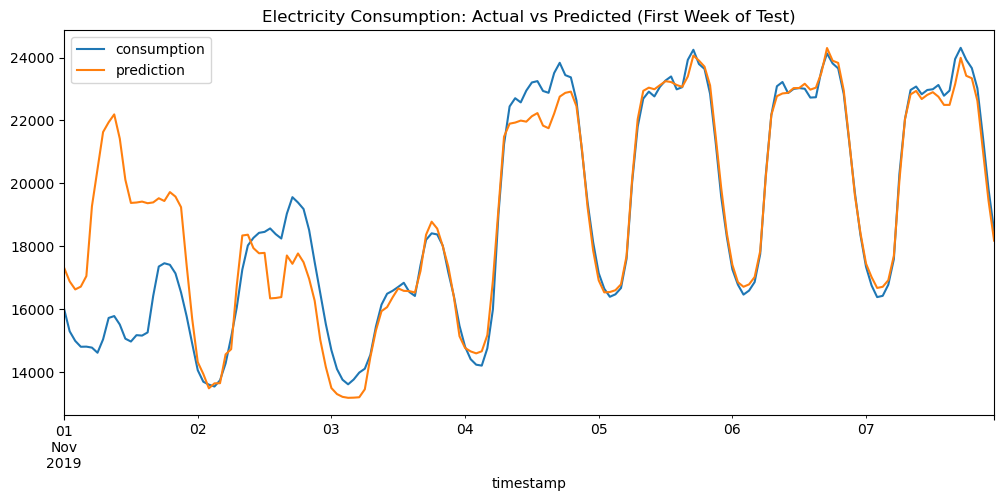

In [9]:
test['prediction'] = model.predict(X_test)

# Plotting the first week of the test set
test.iloc[:168][['consumption', 'prediction']].plot(figsize=(12, 5))
plt.title('Electricity Consumption: Actual vs Predicted (First Week of Test)')
plt.show()

In [10]:
y_pred= model.predict(X_test)

In [11]:
import numpy as np

# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(y_test)

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(y_test - y_pred))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
rrmse = rmse / y_mean

print(f"rMAE:  {rmae:.4f}")
print(f"rRMSE: {rrmse:.4f}")

rMAE:  0.0349
rRMSE: 0.0638
